In [1]:
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

Loading the datasets 

In [2]:
DATA_DIR = Path("../../Datasets")

review_files = [
    DATA_DIR / "reviews_0-250.csv",
    DATA_DIR / "reviews_250-500.csv",
    DATA_DIR / "reviews_500-750.csv",
    DATA_DIR / "reviews_750-1250.csv",
    DATA_DIR / "reviews_1250-end.csv",
]

df_reviews = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)
df_reviews = df_reviews.drop(columns=["Unnamed: 0"], errors="ignore")

print("Reviews shape:", df_reviews.shape)
df_reviews.head()

/var/folders/57/vnd70s_n33xdwqkg8pdrndwc0000gn/T/ipykernel_57206/3081253416.py:11: DtypeWarning: Columns (0: author_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reviews = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)
/var/folders/57/vnd70s_n33xdwqkg8pdrndwc0000gn/T/ipykernel_57206/3081253416.py:11: DtypeWarning: Columns (0: author_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reviews = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)


Reviews shape: (1094411, 18)


/var/folders/57/vnd70s_n33xdwqkg8pdrndwc0000gn/T/ipykernel_57206/3081253416.py:11: DtypeWarning: Columns (0: author_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reviews = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)


,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0


This contains product-level information such as category, brand, price, and ingredients.

In [3]:
df_products = pd.read_csv(DATA_DIR / "product_info.csv")

df_products = df_products.rename(
    columns={
        "rating": "avg_product_rating",
        "reviews": "num_reviews"
    }
)

print("Products shape:", df_products.shape)
df_products.head()

Products shape: (8494, 27)


,product_id,product_name,brand_id,brand_name,loves_count,avg_product_rating,num_reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


We only want skincare recommendations, so we filter the product table to skincare.

In [4]:
df_products = df_products[df_products["primary_category"] == "Skincare"].copy()

print("Skincare products:", df_products.shape)
print(df_products["primary_category"].value_counts(dropna=False))

Skincare products: (2420, 27)
primary_category
Skincare    2420
Name: count, dtype: int64


#### Merge reviews with skincare product info: This keeps only the reviews that belong to skincare products and attaches product metadata.

In [5]:
product_cols = [
    "product_id", "product_name", "brand_name", "ingredients", "price_usd",
    "highlights", "primary_category", "secondary_category", "tertiary_category",
    "avg_product_rating", "num_reviews", "loves_count", "sale_price_usd", "value_price_usd"
]

df_merged = df_reviews.merge(
    df_products[product_cols],
    on="product_id",
    how="inner"
)

print("Merged skincare review data shape:", df_merged.shape)
df_merged.head()

Merged skincare review data shape: (1094411, 31)


,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,...,price_usd_y,highlights,primary_category,secondary_category,tertiary_category,avg_product_rating,num_reviews,loves_count,sale_price_usd,value_price_usd
0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,...,19.0,['Clean at Sephora'],Skincare,Cleansers,NaN,5.0000,1.0,177,NaN,NaN
1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,...,24.0,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,4.3508,16118.0,1081315,NaN,NaN
2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,...,24.0,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,4.3508,16118.0,1081315,NaN,NaN
3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,...,24.0,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,4.3508,16118.0,1081315,NaN,NaN
4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,...,24.0,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,4.3508,16118.0,1081315,NaN,NaN


#### Keep only the columns needed for collaborative filtering

For the rating model, the core information is:

- user id
- product id
- rating

We keep metadata separately for later display and possible hybrid extensions.

In [6]:
df_interactions = df_merged[["author_id", "product_id", "rating"]].copy()
df_interactions = df_interactions.dropna(subset=["author_id", "product_id", "rating"])

print("Interaction rows before deduplication:", len(df_interactions))
df_interactions.head()

Interaction rows before deduplication: 1094411


,author_id,product_id,rating
0,1741593524,P504322,5
1,31423088263,P420652,1
2,5061282401,P420652,5
3,6083038851,P420652,5
4,47056667835,P420652,5


Sometimes the same user rated the same product more than once.
We collapse those duplicates into one average rating per user-product pair.

In [7]:
duplicate_pairs = df_interactions.duplicated(subset=["author_id", "product_id"]).sum()
print("Duplicate user-product pairs:", duplicate_pairs)

df_interactions = (
    df_interactions
    .groupby(["author_id", "product_id"], as_index=False)["rating"]
    .mean()
)

print("Interaction rows after deduplication:", len(df_interactions))
df_interactions.head()

Duplicate user-product pairs: 5520
Interaction rows after deduplication: 1088891


,author_id,product_id,rating
0,538863,P420652,1.0
1,549704,P218700,5.0
2,557770,P232903,5.0
3,561736,P421998,5.0
4,561736,P445951,5.0


### sparsity check: This tells us how many users, products, and ratings we have before filtering.

In [8]:
n_users_raw = df_interactions["author_id"].nunique()
n_products_raw = df_interactions["product_id"].nunique()
n_ratings_raw = len(df_interactions)

print("Unique users:", n_users_raw)
print("Unique products:", n_products_raw)
print("Observed ratings:", n_ratings_raw)

print("\nRating distribution:")
print(df_interactions["rating"].value_counts().sort_index())

Unique users: 578653
Unique products: 2351
Observed ratings: 1088891

Rating distribution:
rating
1.000000     60925
1.500000        55
1.666667         1
2.000000     52807
2.500000        66
2.666667         4
3.000000     81510
3.200000         1
3.250000         1
3.333333         3
3.500000       152
3.666667         4
4.000000    198351
4.200000         1
4.250000         3
4.333333         8
4.400000         2
4.428571         1
4.500000       584
4.666667        32
4.750000         6
4.800000         3
4.833333         1
4.983051         1
5.000000    694369
Name: count, dtype: int64


### Filter to active users and products

This step reduces extreme sparsity.
We keep:
- users with at least 10 ratings
- products with at least 20 ratings

This makes collaborative filtering more stable.

In [9]:
MIN_USER_RATINGS = 10
MIN_PRODUCT_RATINGS = 20

user_counts = df_interactions["author_id"].value_counts()
product_counts = df_interactions["product_id"].value_counts()

active_users = user_counts[user_counts >= MIN_USER_RATINGS].index
active_products = product_counts[product_counts >= MIN_PRODUCT_RATINGS].index

df_cf = df_interactions[
    df_interactions["author_id"].isin(active_users) &
    df_interactions["product_id"].isin(active_products)
].copy()

print("Filtered interaction rows:", len(df_cf))
print("Filtered unique users:", df_cf["author_id"].nunique())
print("Filtered unique products:", df_cf["product_id"].nunique())

Filtered interaction rows: 133720
Filtered unique users: 7029
Filtered unique products: 1752


### Build a user-product matrix 

In [10]:
A = df_cf.pivot(index="author_id", columns="product_id", values="rating")

n_users, n_products = A.shape
total_cells = n_users * n_products
observed_cells = A.notna().sum().sum()
missing_cells = total_cells - observed_cells
missing_pct = 100 * missing_cells / total_cells

print("Matrix shape:", A.shape)
print("Observed cells:", observed_cells)
print("Missing cells:", missing_cells)
print(f"Missing %: {missing_pct:.2f}%")

Matrix shape: (7029, 1752)
Observed cells: 133720
Missing cells: 12181088
Missing %: 98.91%


#### Create a per-user holdout split

Instead of a simple random split over all rows, we hold out **one rating per user** for evaluation.
This is better for recommenders because we want to test whether the model can recover something a user actually liked or rated.

Instead of randomly splitting all rows, it does this:

for each user
pick one rating
put that one rating into the test set
keep the rest of that user’s ratings in the train set

So every user appears in both: train & test

In [11]:
rng = np.random.default_rng(42)

test_idx = (
    df_cf.groupby("author_id", group_keys=False)
    .apply(lambda x: x.sample(1, random_state=42))
    .index
)

test_df = df_cf.loc[test_idx].copy()
train_df = df_cf.drop(index=test_idx).copy()

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train users:", train_df["author_id"].nunique())
print("Test users:", test_df["author_id"].nunique())

Train rows: 126691
Test rows: 7029
Train users: 7029
Test users: 7029


Suppose a user has rated 10 items.

With this split:

train gets 9
test gets 1

Now the model sees 9 items the user liked/disliked, and tries to predict the 10th.

#### Remove cold-start rows from test

For evaluation, every test user and test product must also appear in training.
This avoids impossible cases for pure collaborative filtering.

In [12]:
train_users = set(train_df["author_id"].unique())
train_products = set(train_df["product_id"].unique())

test_df = test_df[
    test_df["author_id"].isin(train_users) &
    test_df["product_id"].isin(train_products)
].copy()

print("Test rows after cold-start filtering:", len(test_df))

Test rows after cold-start filtering: 7017


#### Build lookup dictionaries

In [13]:
# Make ID columns consistent
train_df["author_id"] = train_df["author_id"].astype(str)
train_df["product_id"] = train_df["product_id"].astype(str)
test_df["author_id"] = test_df["author_id"].astype(str)
test_df["product_id"] = test_df["product_id"].astype(str)

# Create sorted unique user and item lists
user_ids = np.sort(train_df["author_id"].unique())
item_ids = np.sort(train_df["product_id"].unique())

# Create mappings
user_to_idx = {u: i for i, u in enumerate(user_ids)}
item_to_idx = {p: j for j, p in enumerate(item_ids)}

idx_to_user = {i: u for u, i in user_to_idx.items()}
idx_to_item = {j: p for p, j in item_to_idx.items()}

n_users = len(user_ids)
n_items = len(item_ids)

print("Number of train users:", n_users)
print("Number of train items:", n_items)

Number of train users: 6798
Number of train items: 1741


A recommender cannot learn a user vector for a user who has no training ratings. So those 231 users are basically cold-start users after the split.

#### Convert train and test data into indexed arrays

In [14]:
train_array = np.column_stack([
    train_df["author_id"].map(user_to_idx).values,
    train_df["product_id"].map(item_to_idx).values,
    train_df["rating"].values
])

test_array = np.column_stack([
    test_df["author_id"].map(user_to_idx).values,
    test_df["product_id"].map(item_to_idx).values,
    test_df["rating"].values
])

train_array[:5]

array([[3.486e+03, 4.700e+01, 5.000e+00],
       [3.486e+03, 8.200e+01, 4.000e+00],
       [3.486e+03, 1.460e+02, 3.000e+00],
       [3.486e+03, 3.480e+02, 5.000e+00],
       [3.486e+03, 4.280e+02, 2.000e+00]])

#### Baseline 1: global mean

This is the simplest possible recommender: predict every rating as the overall average rating.

rating = mean

In [15]:
global_mean = train_df["rating"].mean()

baseline_global_preds = np.full(len(test_df), global_mean)
rmse_global = np.sqrt(mean_squared_error(test_df["rating"], baseline_global_preds))
mae_global = mean_absolute_error(test_df["rating"], baseline_global_preds)

print(f"Global mean RMSE: {rmse_global:.4f}")
print(f"Global mean MAE : {mae_global:.4f}")

Global mean RMSE: 0.9892
Global mean MAE : 0.7230


#### Baseline 2: user mean + item mean 

rating = mean + item bias + user bias

In [16]:
user_mean = train_df.groupby("author_id")["rating"].mean()
item_mean = train_df.groupby("product_id")["rating"].mean()

def predict_baseline(user_id, product_id):
    u_mean = user_mean.get(user_id, global_mean)
    i_mean = item_mean.get(product_id, global_mean)
    return np.clip(global_mean + (u_mean - global_mean) + (i_mean - global_mean), 1, 5)

baseline_ui_preds = np.array([
    predict_baseline(u, p)
    for u, p in zip(test_df["author_id"], test_df["product_id"])
])

rmse_ui = np.sqrt(mean_squared_error(test_df["rating"], baseline_ui_preds))
mae_ui = mean_absolute_error(test_df["rating"], baseline_ui_preds)

print(f"User+Item baseline RMSE: {rmse_ui:.4f}")
print(f"User+Item baseline MAE : {mae_ui:.4f}")

User+Item baseline RMSE: 0.8864
User+Item baseline MAE : 0.5751


#### Matrix factorization model with biases

Model form:

rating = global mean + user bias + item bias + latent vectors

In [17]:
class BiasedMatrixFactorization:
    def __init__(
        self,
        n_users,
        n_items,
        n_factors=20,
        lr=0.01,
        reg=0.05,
        n_epochs=42,
        random_state=42
    ):
        self.n_users = n_users
        self.n_items = n_items
        self.n_factors = n_factors
        self.lr = lr
        self.reg = reg
        self.n_epochs = n_epochs
        self.random_state = random_state

    def fit(self, train_array, val_array=None, verbose=True):
        rng = np.random.default_rng(self.random_state)

        self.mu = float(np.mean(train_array[:, 2]))
        self.bu = np.zeros(self.n_users)
        self.bi = np.zeros(self.n_items)
        self.P = 0.1 * rng.normal(size=(self.n_users, self.n_factors))
        self.Q = 0.1 * rng.normal(size=(self.n_items, self.n_factors))

        self.train_history_ = []
        self.val_history_ = []

        for epoch in range(1, self.n_epochs + 1):
            shuffled = train_array.copy()
            rng.shuffle(shuffled)

            for u, i, r in shuffled:
                u = int(u)
                i = int(i)
                r = float(r)

                pred = self.mu + self.bu[u] + self.bi[i] + np.dot(self.P[u], self.Q[i])
                err = r - pred

                self.bu[u] += self.lr * (err - self.reg * self.bu[u])
                self.bi[i] += self.lr * (err - self.reg * self.bi[i])

                p_old = self.P[u].copy()
                q_old = self.Q[i].copy()

                self.P[u] += self.lr * (err * q_old - self.reg * p_old)
                self.Q[i] += self.lr * (err * p_old - self.reg * q_old)

            train_pred = self.predict_many(train_array[:, 0], train_array[:, 1])
            train_rmse = np.sqrt(mean_squared_error(train_array[:, 2], train_pred))
            self.train_history_.append(train_rmse)

            if val_array is not None and len(val_array) > 0:
                val_pred = self.predict_many(val_array[:, 0], val_array[:, 1])
                val_rmse = np.sqrt(mean_squared_error(val_array[:, 2], val_pred))
                self.val_history_.append(val_rmse)

                if verbose:
                    print(f"Epoch {epoch:02d} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")
            else:
                if verbose:
                    print(f"Epoch {epoch:02d} | Train RMSE: {train_rmse:.4f}")

        return self

    def predict_one(self, u, i):
        u = int(u)
        i = int(i)
        pred = self.mu + self.bu[u] + self.bi[i] + np.dot(self.P[u], self.Q[i])
        return float(np.clip(pred, 1, 5))

    def predict_many(self, users, items):
        users = np.asarray(users, dtype=int)
        items = np.asarray(items, dtype=int)

        preds = (
            self.mu
            + self.bu[users]
            + self.bi[items]
            + np.sum(self.P[users] * self.Q[items], axis=1)
        )
        return np.clip(preds, 1, 5)

#### Train the matrix factorization model

In [18]:
mf_model = BiasedMatrixFactorization(
    n_users=n_users,
    n_items=n_items,
    n_factors=20,
    lr=0.01,
    reg=0.05,
    n_epochs=42,
    random_state=42
)

mf_model.fit(train_array, val_array=test_array, verbose=True)

Epoch 01 | Train RMSE: 0.8295 | Val RMSE: 0.9236
Epoch 02 | Train RMSE: 0.7962 | Val RMSE: 0.9009
Epoch 03 | Train RMSE: 0.7751 | Val RMSE: 0.8855
Epoch 04 | Train RMSE: 0.7597 | Val RMSE: 0.8753
Epoch 05 | Train RMSE: 0.7477 | Val RMSE: 0.8679
Epoch 06 | Train RMSE: 0.7377 | Val RMSE: 0.8625
Epoch 07 | Train RMSE: 0.7290 | Val RMSE: 0.8585
Epoch 08 | Train RMSE: 0.7209 | Val RMSE: 0.8537
Epoch 09 | Train RMSE: 0.7129 | Val RMSE: 0.8507
Epoch 10 | Train RMSE: 0.7051 | Val RMSE: 0.8480
Epoch 11 | Train RMSE: 0.6967 | Val RMSE: 0.8443
Epoch 12 | Train RMSE: 0.6879 | Val RMSE: 0.8414
Epoch 13 | Train RMSE: 0.6785 | Val RMSE: 0.8375
Epoch 14 | Train RMSE: 0.6684 | Val RMSE: 0.8341
Epoch 15 | Train RMSE: 0.6580 | Val RMSE: 0.8308
Epoch 16 | Train RMSE: 0.6469 | Val RMSE: 0.8264
Epoch 17 | Train RMSE: 0.6358 | Val RMSE: 0.8225
Epoch 18 | Train RMSE: 0.6243 | Val RMSE: 0.8193
Epoch 19 | Train RMSE: 0.6129 | Val RMSE: 0.8157
Epoch 20 | Train RMSE: 0.6015 | Val RMSE: 0.8125
Epoch 21 | Train RMS

#### Evaluate the matrix factorization model

In [19]:
mf_test_preds = mf_model.predict_many(test_array[:, 0], test_array[:, 1])

rmse_mf = np.sqrt(mean_squared_error(test_array[:, 2], mf_test_preds))
mae_mf = mean_absolute_error(test_array[:, 2], mf_test_preds)

results = pd.DataFrame({
    "Model": ["Global Mean", "User+Item Baseline", "Biased MF"],
    "RMSE": [rmse_global, rmse_ui, rmse_mf],
    "MAE": [mae_global, mae_ui, mae_mf]
}).sort_values("RMSE")

results

,Model,RMSE,MAE
2,Biased MF,0.793183,0.498573
1,User+Item Baseline,0.886445,0.575147
0,Global Mean,0.989223,0.722996


#### Plot the training curve

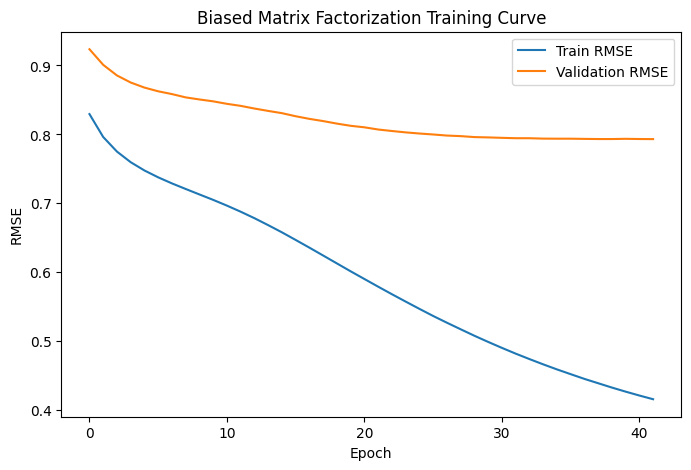

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(mf_model.train_history_, label="Train RMSE")
plt.plot(mf_model.val_history_, label="Validation RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Biased Matrix Factorization Training Curve")
plt.legend()
plt.show()

#### prediction table for known users and products

This function gives predicted ratings for products a user has **not** already rated in the training set.

In [21]:
train_user_items = (
    train_df.groupby("author_id")["product_id"]
    .apply(set)
    .to_dict()
)

def recommend_for_user_mf(user_id, model, train_user_items, user_to_idx, item_to_idx, top_n=10):
    if user_id not in user_to_idx:
        return pd.DataFrame(columns=["product_id", "predicted_rating"])

    rated_items = train_user_items.get(user_id, set())
    candidate_items = [p for p in item_to_idx.keys() if p not in rated_items]

    u_idx = user_to_idx[user_id]
    preds = []

    for product_id in candidate_items:
        i_idx = item_to_idx[product_id]
        pred = model.predict_one(u_idx, i_idx)
        preds.append((product_id, pred))

    recs = pd.DataFrame(preds, columns=["product_id", "predicted_rating"])
    recs = recs.sort_values("predicted_rating", ascending=False).head(top_n).reset_index(drop=True)
    return recs

#### Attach product names to recommendations

In [22]:
def attach_product_info(recs, df_products):
    info_cols = ["product_id", "product_name", "brand_name", "primary_category", "price_usd", "avg_product_rating"]
    return recs.merge(df_products[info_cols], on="product_id", how="left")

sample_user = train_df["author_id"].iloc[0]

sample_recs = recommend_for_user_mf(
    user_id=sample_user,
    model=mf_model,
    train_user_items=train_user_items,
    user_to_idx=user_to_idx,
    item_to_idx=item_to_idx,
    top_n=10
)

sample_recs = attach_product_info(sample_recs, df_products)
sample_recs

,product_id,predicted_rating,product_name,brand_name,primary_category,price_usd,avg_product_rating
0,P440307,5.0,Superberry Hydrate + Glow Dream Night Mask wit...,Youth To The People,Skincare,52.0,4.3237
1,P484080,5.0,Mini Faded Serum for Dark Spots & Discoloration,Topicals,Skincare,18.0,3.6634
2,P385773,5.0,Hyaluronic Marine Hydration Booster,Dr. Dennis Gross Skincare,Skincare,72.0,4.2555
3,P429515,5.0,C-Tango Vitamin C Eye Cream,Drunk Elephant,Skincare,64.0,3.7473
4,P446938,5.0,Lala Retro Whipped Refillable Moisturizer with...,Drunk Elephant,Skincare,62.0,4.1535
5,P432668,5.0,D-Bronzi Anti-Pollution Bronzing Drops with Pe...,Drunk Elephant,Skincare,38.0,4.4330
6,P394124,5.0,Argan Daily Moisturizer Tinted SPF 47 Protect ...,Josie Maran,Skincare,38.0,4.0123
7,P384537,5.0,GENIUS Ultimate Anti-Aging Cream,Algenist,Skincare,112.0,4.2525
8,P503052,5.0,Mini Flatter Me Digestive Enzyme Supplement,HUM Nutrition,Skincare,15.0,4.2643
9,P436387,5.0,Overtime Mask,Summer Fridays,Skincare,49.0,4.4087


#### Check a user's known ratings versus predicted ratings

In [23]:
def compare_known_ratings(user_id, train_df, model, user_to_idx, item_to_idx, df_products, top_n=20):
    if user_id not in user_to_idx:
        return pd.DataFrame()

    user_known = train_df[train_df["author_id"] == user_id].copy()
    user_known["predicted_rating"] = [
        model.predict_one(user_to_idx[user_id], item_to_idx[p])
        for p in user_known["product_id"]
    ]

    user_known = user_known.merge(
        df_products[["product_id", "product_name", "brand_name"]],
        on="product_id",
        how="left"
    )

    return user_known.sort_values("rating", ascending=False).head(top_n)

compare_known_ratings(
    user_id=sample_user,
    train_df=train_df,
    model=mf_model,
    user_to_idx=user_to_idx,
    item_to_idx=item_to_idx,
    df_products=df_products,
    top_n=20
)

,author_id,product_id,rating,predicted_rating,product_name,brand_name
0,2760276,P232915,5.0,5.000000,ExfoliKate Intensive Pore Exfoliating Treatment,Kate Somerville
21,2760276,P394639,5.0,5.000000,The True Cream Aqua Bomb,belif
27,2760276,P415747,5.0,4.564254,Brazilian Kiss Cupuaçu Lip Butter,Sol de Janeiro
30,2760276,P423688,5.0,4.499652,Daily Microfoliant Exfoliator,Dermalogica
34,2760276,P427421,5.0,4.354392,Protini Polypeptide Firming Refillable Moistur...,Drunk Elephant
35,2760276,P428668,5.0,4.864147,Baggage Claim Eye Masks,Wander Beauty
36,2760276,P428816,5.0,4.613076,Noni Radiant Brightening Eye Oil,KORA Organics
37,2760276,P432045,5.0,4.105855,GENIUS Liquid Collagen Lip Treatment,Algenist
38,2760276,P432823,5.0,4.680425,Gua Sha Facial Lifting Tool,Mount Lai
39,2760276,P434548,5.0,4.549091,Honeymoon Glow AHA Resurfacing Night Serum,Farmacy


#### Ranking evaluation: Hit Rate @ K

In [24]:
def hit_rate_at_k(model, train_df, test_df, user_to_idx, item_to_idx, k=10):
    train_user_items = train_df.groupby("author_id")["product_id"].apply(set).to_dict()

    hits = 0
    total = 0

    for _, row in test_df.iterrows():
        user_id = row["author_id"]
        true_item = row["product_id"]

        if user_id not in user_to_idx or true_item not in item_to_idx:
            continue

        rated_items = train_user_items.get(user_id, set())
        candidate_items = [p for p in item_to_idx.keys() if p not in rated_items]

        if len(candidate_items) == 0:
            continue

        u_idx = user_to_idx[user_id]
        preds = []

        for product_id in candidate_items:
            i_idx = item_to_idx[product_id]
            preds.append((product_id, model.predict_one(u_idx, i_idx)))

        top_k_items = [p for p, _ in sorted(preds, key=lambda x: x[1], reverse=True)[:k]]

        hits += int(true_item in top_k_items)
        total += 1

    return hits / total if total > 0 else np.nan

for k in [5, 10, 20]:
    hr = hit_rate_at_k(mf_model, train_df, test_df, user_to_idx, item_to_idx, k=k)
    print(f"Hit Rate @{k}: {hr:.4f}")

Hit Rate @5: 0.0053
Hit Rate @10: 0.0101
Hit Rate @20: 0.0212


#### hyperparameter tuning

In [25]:
param_grid = [
    {"n_factors": 10, "reg": 0.02},
    {"n_factors": 20, "reg": 0.05},
    {"n_factors": 40, "reg": 0.05},
    {"n_factors": 30, "reg": 0.10},
]

tuning_results = []

for params in param_grid:
    model = BiasedMatrixFactorization(
        n_users=n_users,
        n_items=n_items,
        n_factors=params["n_factors"],
        lr=0.01,
        reg=params["reg"],
        n_epochs=15,
        random_state=42
    )
    model.fit(train_array, val_array=test_array, verbose=False)
    preds = model.predict_many(test_array[:, 0], test_array[:, 1])
    rmse = np.sqrt(mean_squared_error(test_array[:, 2], preds))
    mae = mean_absolute_error(test_array[:, 2], preds)

    tuning_results.append({
        "n_factors": params["n_factors"],
        "reg": params["reg"],
        "RMSE": rmse,
        "MAE": mae
    })

pd.DataFrame(tuning_results).sort_values("RMSE")

,n_factors,reg,RMSE,MAE
2,40,0.05,0.816580,0.537232
0,10,0.02,0.824748,0.541045
1,20,0.05,0.830823,0.547031
3,30,0.10,0.837165,0.553061


#### Save the final prediction-ready objects

This keeps the most important objects together for later recommendation work.

In [26]:
artifacts = {
    "train_df": train_df,
    "test_df": test_df,
    "df_products": df_products,
    "user_to_idx": user_to_idx,
    "item_to_idx": item_to_idx,
    "train_user_items": train_user_items,
    "mf_model": mf_model
}

print("Artifacts ready:", list(artifacts.keys()))

Artifacts ready: ['train_df', 'test_df', 'df_products', 'user_to_idx', 'item_to_idx', 'train_user_items', 'mf_model']


**Cell 1: Matrix Artifact Export Setup**

In [27]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "ishita").exists():
            return candidate
    return start

ROOT = find_project_root()
ARTIFACT_DIR = ROOT / "artifacts"
MATRIX_DIR = ARTIFACT_DIR / "matrix"

MATRIX_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Matrix artifact directory:", MATRIX_DIR)


Project root: /Users/veerr_89/Work/projects/up-skin
Matrix artifact directory: /Users/veerr_89/Work/projects/up-skin/artifacts/matrix


**Cell 2: Normalize IDs Before Export**

In [28]:
# Keep IDs stable for downstream joins.
train_df = train_df.copy()
test_df = test_df.copy()
df_products = df_products.copy()

train_df["author_id"] = train_df["author_id"].astype(str)
train_df["product_id"] = train_df["product_id"].astype(str)

test_df["author_id"] = test_df["author_id"].astype(str)
test_df["product_id"] = test_df["product_id"].astype(str)

df_products["product_id"] = df_products["product_id"].astype(str)

# Rebuild lookup dictionaries from final train_df.
user_ids = np.sort(train_df["author_id"].unique())
item_ids = np.sort(train_df["product_id"].unique())

user_to_idx = {u: i for i, u in enumerate(user_ids)}
item_to_idx = {p: j for j, p in enumerate(item_ids)}

print("Train users:", len(user_to_idx))
print("Train items:", len(item_to_idx))


Train users: 6798
Train items: 1741


**Cell 3: Export Train/Test/Product/User History**

In [29]:
train_df.to_csv(MATRIX_DIR / "train_df.csv", index=False)
test_df.to_csv(MATRIX_DIR / "test_df.csv", index=False)
df_products.to_csv(MATRIX_DIR / "skincare_products.csv", index=False)

user_history = (
    train_df.sort_values(["author_id", "product_id"])
    .groupby("author_id")
    .agg(
        user_rating_count=("rating", "size"),
        mean_user_rating=("rating", "mean"),
        rated_product_ids=("product_id", lambda x: "|".join(x.astype(str))),
    )
    .reset_index()
)

liked_products = (
    train_df[train_df["rating"] >= 4.0]
    .sort_values(["author_id", "product_id"])
    .groupby("author_id")["product_id"]
    .agg(lambda x: "|".join(x.astype(str)))
    .rename("liked_product_ids")
    .reset_index()
)

user_history = user_history.merge(liked_products, on="author_id", how="left")
user_history["liked_product_ids"] = user_history["liked_product_ids"].fillna("")

user_history.to_csv(MATRIX_DIR / "user_history.csv", index=False)

print("Saved train/test/products/user history.")
print("user_history:", user_history.shape)


Saved train/test/products/user history.
user_history: (6798, 5)


**Cell 4: Export MF Predictions On Test Set**

In [30]:
test_export = test_df.copy().reset_index(drop=True)

test_export = test_export[
    test_export["author_id"].isin(user_to_idx) &
    test_export["product_id"].isin(item_to_idx)
].copy()

test_user_idx = test_export["author_id"].map(user_to_idx).astype(int).to_numpy()
test_item_idx = test_export["product_id"].map(item_to_idx).astype(int).to_numpy()

mf_scores = mf_model.predict_many(test_user_idx, test_item_idx)

mf_predictions = test_export.rename(columns={"rating": "true_rating"})[
    ["author_id", "product_id", "true_rating"]
].copy()

mf_predictions["mf_score"] = mf_scores

mf_predictions.to_csv(MATRIX_DIR / "mf_predictions_test.csv", index=False)

print("Saved MF predictions:", mf_predictions.shape)
mf_predictions.head()


Saved MF predictions: (7017, 4)


,author_id,product_id,true_rating,mf_score
0,2760276,P448563,3.0,3.856738
1,11777122,P475124,5.0,4.833904
2,967124371,P470065,4.0,4.752689
3,985770407,P504023,5.0,4.928580
4,989697609,P500777,5.0,5.000000


**Cell 5: Export Metrics And Sanity Checks**

In [31]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

global_mean = train_df["rating"].mean()

global_preds = np.full(len(test_export), global_mean)

user_mean = train_df.groupby("author_id")["rating"].mean()
item_mean = train_df.groupby("product_id")["rating"].mean()

def predict_user_item_baseline(user_id, product_id):
    u_mean = user_mean.get(user_id, global_mean)
    i_mean = item_mean.get(product_id, global_mean)
    return np.clip(global_mean + (u_mean - global_mean) + (i_mean - global_mean), 1, 5)

user_item_preds = np.array([
    predict_user_item_baseline(u, p)
    for u, p in zip(test_export["author_id"], test_export["product_id"])
])

metrics = {
    "global_mean": {
        "rmse": rmse(test_export["rating"], global_preds),
        "mae": mae(test_export["rating"], global_preds),
    },
    "user_item_baseline": {
        "rmse": rmse(test_export["rating"], user_item_preds),
        "mae": mae(test_export["rating"], user_item_preds),
    },
    "biased_mf": {
        "rmse": rmse(mf_predictions["true_rating"], mf_predictions["mf_score"]),
        "mae": mae(mf_predictions["true_rating"], mf_predictions["mf_score"]),
    },
}

split_sanity = {
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "train_users": int(train_df["author_id"].nunique()),
    "test_users": int(test_df["author_id"].nunique()),
    "train_products": int(train_df["product_id"].nunique()),
    "test_products": int(test_df["product_id"].nunique()),
    "min_train_ratings_per_user": int(train_df.groupby("author_id").size().min()),
    "test_users_missing_from_train": int((~test_df["author_id"].isin(train_df["author_id"])).sum()),
    "test_products_missing_from_train": int((~test_df["product_id"].isin(train_df["product_id"])).sum()),
}

with open(MATRIX_DIR / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

with open(MATRIX_DIR / "split_sanity.json", "w") as f:
    json.dump(split_sanity, f, indent=2)

print("Saved metrics and split sanity checks.")
print(json.dumps(metrics, indent=2))
print(json.dumps(split_sanity, indent=2))


Saved metrics and split sanity checks.
{
  "global_mean": {
    "rmse": 0.9892227798280819,
    "mae": 0.7229964309741008
  },
  "user_item_baseline": {
    "rmse": 0.8864450310880009,
    "mae": 0.575147265492569
  },
  "biased_mf": {
    "rmse": 0.7931829352149041,
    "mae": 0.4985734531547271
  }
}
{
  "train_rows": 126691,
  "test_rows": 7017,
  "train_users": 6798,
  "test_users": 6797,
  "train_products": 1741,
  "test_products": 1202,
  "min_train_ratings_per_user": 5,
  "test_users_missing_from_train": 0,
  "test_products_missing_from_train": 0
}


**Cell 6: Optional Ranking Metrics Export**

In [32]:
ranking_metrics = {}

for k in [5, 10, 20]:
    ranking_metrics[f"hit_rate_at_{k}"] = float(
        hit_rate_at_k(
            mf_model,
            train_df,
            test_df,
            user_to_idx,
            item_to_idx,
            k=k,
        )
    )

metrics["ranking"] = {
    "mf": ranking_metrics
}

with open(MATRIX_DIR / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Updated metrics with ranking:")
print(json.dumps(metrics["ranking"], indent=2))


Updated metrics with ranking:
{
  "mf": {
    "hit_rate_at_5": 0.005272908650420407,
    "hit_rate_at_10": 0.010118284167022944,
    "hit_rate_at_20": 0.02123414564628759
  }
}
